# 02 - Preprocessing danych

## Cel: 
Czyszczenie danych, agregacja do kroku dobowego, uzupełnianie braków medianą sezonową

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
os.chdir('..')

from src.data.dataset import build_meteo_dataframe, build_water_level_dataframe
from src.data.preprocessing import clean_meteo_and_day_step, fix_missing_meteo, clean_water_level_and_day_step, fix_missing_water_level

### Czyszczenie i Agregacja

#### Dane meteorologiczne

In [2]:
df_meteo_raw = build_meteo_dataframe()
print("Przed czyszczeniem:", df_meteo_raw.shape)

ERROR! Session/line number was not unique in database. History logging moved to new session 2
Przed czyszczeniem: (43680, 5)


In [3]:
df_meteo_clean = clean_meteo_and_day_step(df_meteo_raw)
print("Po czyszczeniu i agregacji dobowej:", df_meteo_clean.shape)
df_meteo_clean.head()

Po czyszczeniu i agregacji dobowej: (1811, 8)


,Opad_suma,Temp_średnia,Temp_min,Temp_max,Wilgotność_średnia,Ciśnienie_średnia,Ciśnienie_min,Ciśnienie_max
Dzień,,,,,,,,
2021-01-01,0.00,-1.170833,-2.2,-0.2,94.341667,1005.466667,1005.0,1006.6
2021-01-02,0.00,0.616667,-0.3,2.3,87.733333,1011.208333,1007.0,1015.7
2021-01-03,2.08,0.558333,-0.8,1.6,91.033333,1016.716667,1015.9,1017.4
2021-01-04,3.61,1.245833,0.6,1.9,90.575000,1016.441667,1015.9,1016.9
2021-01-05,18.58,2.170833,0.9,3.6,91.354167,1013.233333,1009.3,1016.3


#### Metody czyszczenia 
##### Konwersja typów
- Kolumny z danymi surowymi były typu string (object)
- Wartości z przecinkiem dziesiętnym były zastępione kropką, a potem skonwertowane na typ numeryczny
##### Wartości fizycznie niemożliwe
- Wartości które nie mieściły się w zakresie fizycznie możliwych wystąpień zostały zamienione na NaN
- Opad -> min: 0mm, max: 100mm
- Temperature -> min: -30C, max: 40C
- Wilgotność -> min: 0%, max: 100%
- Ciśnienie -> min: 950 hPa, max: 1050 hPa
##### Agregacja do kroku dobowego
- Opad -> suma opadów
- Temperatura -> min, max, średnia
- Wilgotność -> średnia
- Ciśnienie -> min, max, średnia

#### Dane poziomu wody

In [4]:
df_water_level_raw = build_water_level_dataframe()
print("Przed czyszczeniem:", df_water_level_raw.shape)

Przed czyszczeniem: (43672, 2)


In [5]:
df_water_level_clean = clean_water_level_and_day_step(df_water_level_raw)
print("Po czyszczeniu i agregacji dobowej:", df_water_level_clean.shape)
df_water_level_clean.head()

Po czyszczeniu i agregacji dobowej: (1822, 2)


,Poziom_wody_średnia,Poziom_wody_max
Dzień,,
2021-01-01,-0.052917,0.00
2021-01-02,-0.035833,0.00
2021-01-03,0.013333,0.05
2021-01-04,0.015417,0.06
2021-01-05,0.018750,0.10


#### Metody czyszczenia 
##### Konwersja typów
- Kolumny z danymi surowymi były typu string (object)
- Wartości z przecinkiem dziesiętnym były zastępione kropką, a potem skonwertowane na typ numeryczny
##### Agregacja do kroku dobowego
- Poziom wody -> średnia dobowa i maksimum dobowe

### Analiza braków na poziomie godzinowym

In [6]:
import missingno as msno
import os

all_dfs = []
folder = 'data/raw/dane-pogodowe-stacja-gora-gradowa-2021-2025/'
for file in os.listdir(folder):
    if file.endswith('.xlsx'):
        df = pd.read_excel(folder + file, skipfooter=4)
        df = df.dropna(how='all')
        df.columns = df.columns.str.strip()
        all_dfs.append(df)

df_all = pd.concat(all_dfs)
cols = ['Opad [mm]', 'Temperatura [C]', 'Wilgotność [%]', 'Ciśnienie [hPa]']
for col in cols:
    df_all[col] = df_all[col].astype(str).str.replace(',', '.')
    df_all[col] = pd.to_numeric(df_all[col], errors='coerce')

print("Braki w surowych danych godzinowych:")
print(df_all[cols].isnull().sum())
print("\nProcent braków:")
print((df_all[cols].isnull().sum() / len(df_all) * 100).round(2))

Braki w surowych danych godzinowych:
Opad [mm]          264
Temperatura [C]    433
Wilgotność [%]     433
Ciśnienie [hPa]    433
dtype: int64

Procent braków:
Opad [mm]          0.60
Temperatura [C]    0.99
Wilgotność [%]     0.99
Ciśnienie [hPa]    0.99
dtype: float64


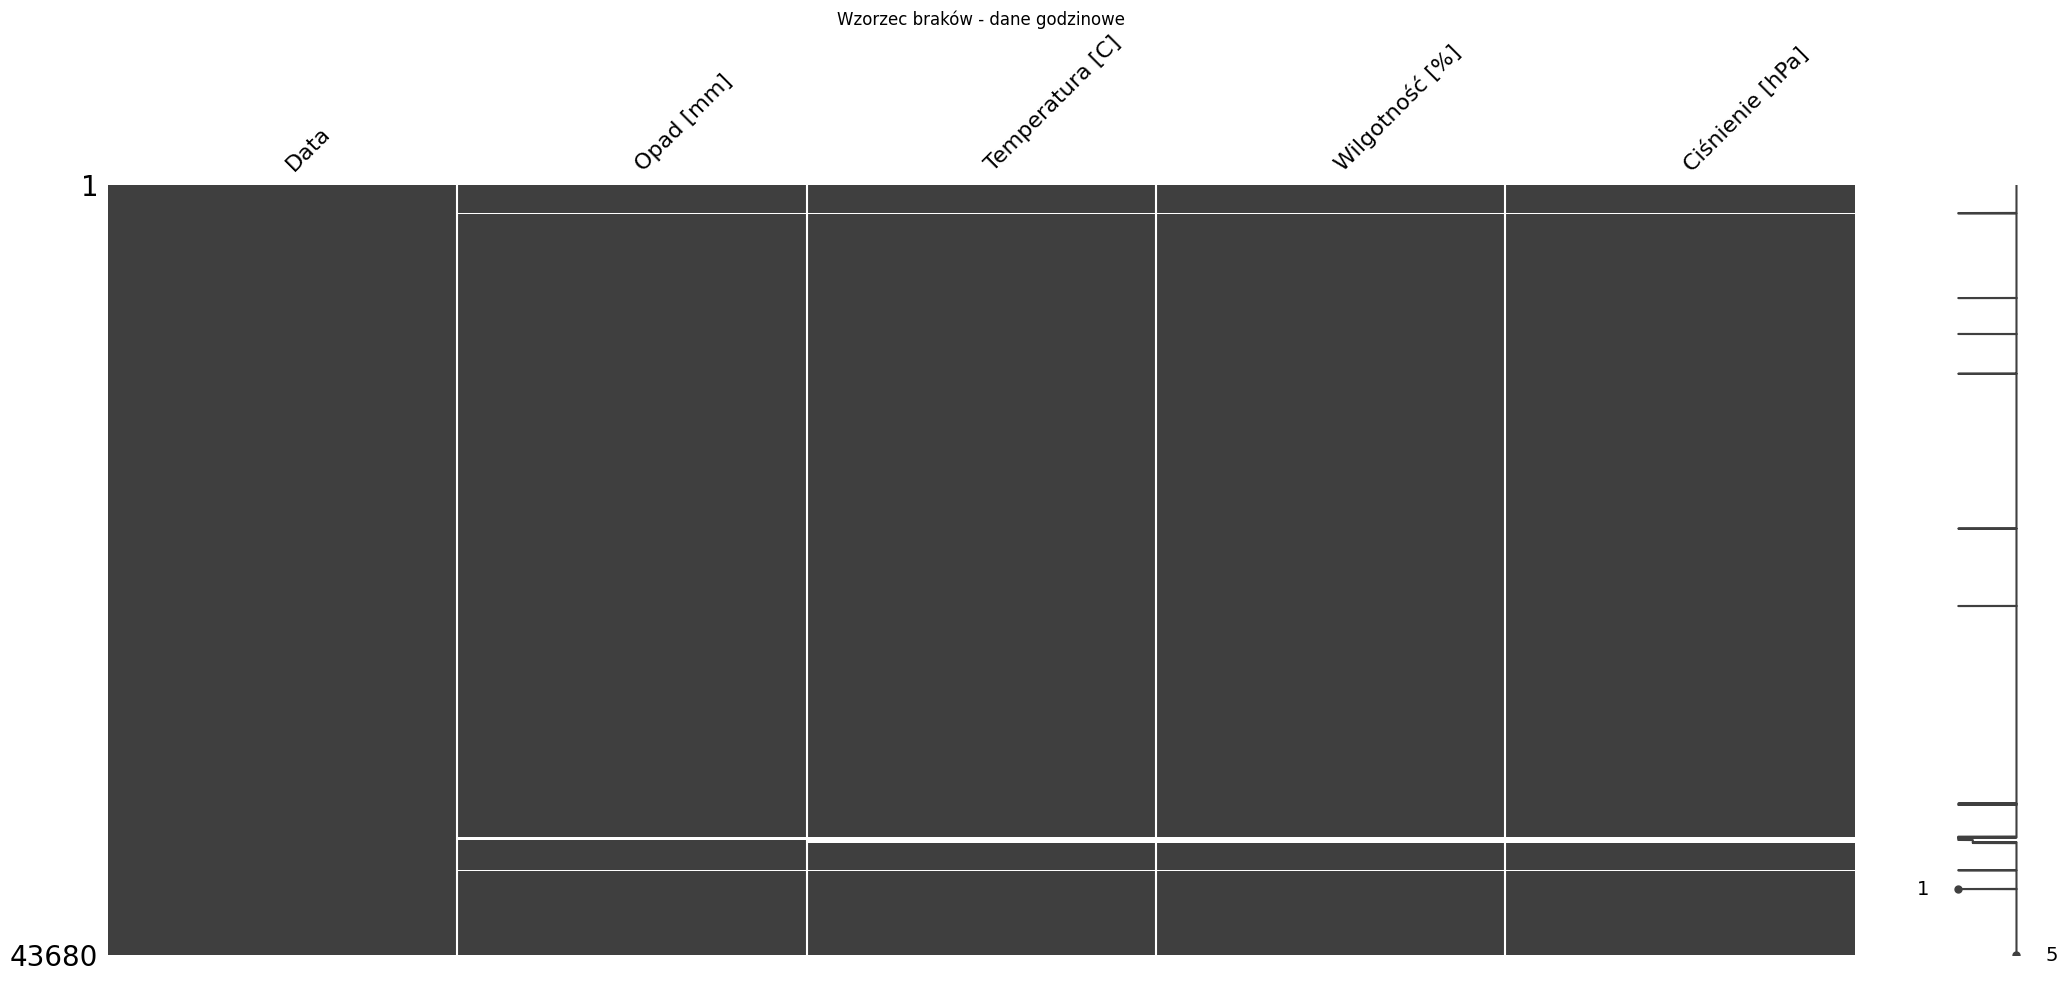

In [10]:
os.makedirs('reports/02_preprocessing', exist_ok=True)

msno.matrix(df_all)
plt.title('Wzorzec braków - dane godzinowe')
plt.savefig('reports/02_preprocessing/missing_data.png', dpi=300, bbox_inches='tight')
plt.show()

### Obserwacje z wizualizacji braków

Macierz braków (missingno) pokazuje że dane godzinowe są 
kompletne w ~99% całego okresu 2021-2025. Widoczne są jedynie
pojedyncze białe paski na końcu zbioru danych, odpowiadające
niekompletnemu ostatniemu dniu pomiarowemu.

Braki mają charakter **MCAR (Missing Completely At Random)** —
nie wykazują żadnego systematycznego wzorca czasowego ani
sezonowego, co potwierdza że są wynikiem losowych przerw
w pomiarach, a nie błędów systematycznych.

### Uzasadnienie wybranej strategii uzupełniania braków

Przeanalizowano możliwe strategie imputacji opisane w literaturze:

| Strategia | Ocena | Powód odrzucenia |
|-----------|-------|-----------------|
| KNN Imputer | nie | Nieuzasadniony przy <1% braków |
| Interpolacja liniowa | nie | Ryzykowna dla danych z silną sezonowością |
| Forward/backward fill | nie | Może propagować błędy pomiarowe |
| **Listwise deletion** | tak | Stosowana na poziomie godzinowym — usunięcie <1% wierszy nie zniekształca danych |
| **Seasonal median imputation** | tak | Stosowana na poziomie dobowym — zachowuje sezonowość danych |

### Dlaczego agregacja jest bezpieczna?

Dane godzinowe są kompletne w ~99%. Oznacza to że:
- Każdy dzień ma prawie kompletne 24 godziny pomiarów
- Agregacja dobowa (średnia/suma z dostępnych godzin) 
  jest reprezentatywna
- Braki godzinowe są "absorbowane" przez groupby
- Jedyne realne braki to brakujące całe dni po reindex —
  uzupełniane medianą sezonową

### Uzupełnianie Brakujących danych

#### Dane meteorologiczne

In [7]:
print("Braki przed uzupełnieniem:")
print(df_meteo_clean.isnull().sum())

Braki przed uzupełnieniem:
Opad_suma             0
Temp_średnia          0
Temp_min              0
Temp_max              0
Wilgotność_średnia    0
Ciśnienie_średnia     0
Ciśnienie_min         0
Ciśnienie_max         0
dtype: int64


In [8]:
df_meteo_filled = fix_missing_meteo(df_meteo_clean)

print("\nBraki po uzupełnieniu:")
print(df_meteo_filled.isnull().sum())


Braki po uzupełnieniu:
Opad_suma             0
Temp_średnia          0
Temp_min              0
Temp_max              0
Wilgotność_średnia    0
Ciśnienie_średnia     0
Ciśnienie_min         0
Ciśnienie_max         0
month                 0
dtype: int64


#### Dane poziomu wody

In [11]:
print("Braki przed uzupełnieniem:")
print(df_water_level_clean.isnull().sum())

Braki przed uzupełnieniem:
Poziom_wody_średnia    0
Poziom_wody_max        0
dtype: int64


In [12]:
df_water_level_filled = fix_missing_water_level(df_water_level_clean)

print("\nBraki po uzupełnieniu:")
print(df_water_level_filled.isnull().sum())


Braki po uzupełnieniu:
Poziom_wody_średnia    0
Poziom_wody_max        0
month                  0
dtype: int64
